<a href="https://colab.research.google.com/github/planlane/llm_advanced_s1/blob/main/session1a_shannon_markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JeremieJakubowicz/xhec-advanced-ai-2026/blob/main/Session1/Session1a-Shannon-Markov.ipynb)

# Session 1 (part A) — Shannon's game, Markov language models, and the memorization trap

**Advanced AI: Language Models & Agents** · X-HEC · Fall 2026 · Author: Jérémie Jakubowicz

Before neural networks, before GPUs, before the word *generative* was fashionable, a mathematician asked a question that every language model still answers today:
**given the text so far, how much of what comes next is already decided?**
This notebook rebuilds his experiment from scratch on a corpus of Victor Hugo, turns it into a generator, and then pushes it until it breaks.

**What you will take away from this part**

1. A language model is a table (later: a neural network) that gives the distribution of the *next token* given a *context*. Generation is sampling from that table, one token at a time. The same table also measures how *predictable* the text is.
2. The single most important knob is the **memory** (the length of the context). Too little memory: gibberish. Too much memory: the model **recites the corpus by heart** and becomes mute on anything new.
3. Characters and words are two extreme choices of *unit*. Neither is good. This is the door to **tokenization** (part B) and to **neural language models** (session 2).

In [1]:
# On Google Colab, run this cell first (a few seconds). Everything else this notebook needs is preinstalled there.
# Locally, see the README of this folder for the full list of dependencies.
%pip install -q tiktoken

## 1. 1948: Shannon's question

In *A Mathematical Theory of Communication* (1948), Claude Shannon was not trying to write. He was trying to **measure**. His problem came from the telegraph and the telephone: how many symbols must really be sent to transmit a message, and how much can be left out because the receiver could have guessed it? To answer, he needed a way to say *how uncertain* the next symbol of a message is **when you already know the symbols before it**. That is the founding idea of information theory, and it is worth stating once even though we will not develop it: **uncertainty is not a property of a thing, it is a property of a thing given what you already know about it.** Here the thing is the continuation of a text, and what you know is the text that precedes.

Language was his running example, and his claim was provocative: **language is far more predictable than it feels.** A few letters of context already rule out most of the possible continuations; a few words, almost all of them. To make the point concrete, he ran the experiment we are about to reproduce. It needed no computer. Take a book. To produce an "order-$n$" approximation, look at the last $n$ letters you have written, open the book at a random page, find the first place where these $n$ letters occur, and copy the letter that follows. Repeat.

Here are the samples he printed. We quote them because they are the ancestors of every LLM output you will ever read, but read them the way Shannon did: not as writing, as **evidence**. The more the samples look like English as the context grows, the more of English was already decided by the context.

> **Zero-order (letters equiprobable):** XFOML RXKHRJFFJUJ ZLPWCFWKCYJ FFJEYVKCQSGHYD QPAAMKBZAACIBZLHJQD.
>
> **First-order (letter frequencies):** OCRO HLI RGWR NMIELWIS EU LL NBNESEBYA TH EEI ALHENHTTPA OOBTTVA NAH BRL.
>
> **Second-order (each letter depends on the previous one):** ON IE ANTSOUTINYS ARE T INCTORE ST BE S DEAMY ACHIN D ILONASIVE TUCOOWE AT TEASONARE FUSO TIZIN ANDY TOBE SEACE CTISBE.
>
> **Third-order (each letter depends on the previous two):** IN NO IST LAT WHEY CRATICT FROURE BIRS GROCID PONDENOME OF DEMONSTURES OF THE REPTAGIN IS REGOACTIONA OF CRE.
>
> **First-order word approximation:** REPRESENTING AND SPEEDILY IS AN GOOD APT OR COME CAN DIFFERENT NATURAL HERE HE THE A IN CAME THE TO OF TO EXPERT GRAY COME TO FURNISHES THE LINE MESSAGE HAD BE THESE.
>
> **Second-order word approximation:** THE HEAD AND IN FRONTAL ATTACK ON AN ENGLISH WRITER THAT THE CHARACTER OF THIS POINT IS THEREFORE ANOTHER METHOD FOR THE LETTERS THAT THE TIME OF WHO EVER TOLD THE PROBLEM FOR AN UNEXPECTED.

Three things to notice, because they frame everything that follows:

* **The book is the data, not the model.** The model is the table of counts read off the book: for each context, how often each letter followed it. Shannon's page-flipping is just a way of sampling from that table without writing it down. Nothing in the table understands anything; the statistics of the context are enough to narrow down what comes next and, as a by-product, to produce something. A GPT-5-class model is built from the same kind of data for the same purpose, the distribution of the next token given the context, but it does *not* store a table: it stores a function, a neural network, that compresses those statistics and shares them between contexts it has never seen. Why that matters is the subject of sessions 2 and 3; today, the table will do.
* The only knob is the **memory**: how many previous symbols you look at. Shannon stopped at 3 letters / 2 words because he was doing it by hand. We have a computer; we will go much further and see what happens. An LLM's *context window* is the same knob, with a much longer reach.
* Shannon then went on to *quantify* the predictability. In a follow-up experiment (*Prediction and Entropy of Printed English*, 1951) he asked people to guess the next letter of a text, one letter at a time, and counted how often they were right. The conclusion: with a long enough context, roughly three quarters of the letters of an English text are already implied by what precedes them. The unit he invented for this, the *bit*, and the quantity he defined, *entropy*, are the subject of another course. We keep only his question: **how much of the continuation is already decided by the context?** Every curve in section 4 is an answer to it. And a word for later: the loss function that every modern LLM is trained to minimise is exactly Shannon's measure of the uncertainty on the next token given the context. The objective has not changed since 1948; only the table has.

If you are curious, the 1948 paper is [here](https://people.math.harvard.edu/~ctm/home/text/others/shannon/entropy/entropy.pdf) (section 3 for the experiment) and the 1951 paper [here](https://www.princeton.edu/~wbialek/rome/refs/shannon_51.pdf).

**Vocabulary for the rest of the course.** The symbols are called **tokens**. The $p$ previous tokens are the **context** (or *state*). The table gives, for each context, the **distribution of the next token**. Producing text by drawing from that distribution is **sampling**. The number $p$ is the **memory** (an LLM's *context window* is the same idea, just bigger).

## 2. Our book: Victor Hugo

Instead of Shannon's single book we use a 13.5-million-character corpus of Victor Hugo (speeches, plays, poems, novels). Accents were stripped from part of the texts when they were digitized; we strip the remaining ones so that the whole corpus follows one convention, which is why you will read *eloquence* instead of *éloquence*.

In [ ]:
import os, urllib.request, unicodedata

DATA_URL = "https://raw.githubusercontent.com/JeremieJakubowicz/xhec-advanced-ai-2026/main/data/hugotexts.txt"

def load_corpus(path="hugotexts.txt"):
    """Download the corpus (14 MB) from the course's public GitHub repository, once, then read it."""
    if not os.path.exists(path):
        print("Downloading the corpus from GitHub...")
        urllib.request.urlretrieve(DATA_URL, path)
    return open(path, encoding="utf-8").read()

def strip_accents(text):
    return "".join(ch for ch in unicodedata.normalize("NFD", text) if unicodedata.category(ch) != "Mn")

hugo = strip_accents(load_corpus())
print(f"{len(hugo):,} characters, {len(hugo.split()):,} words")
print(hugo[:700])

13,508,455 characters, 2,207,761 words
ACTES ET PAROLES I





LE DROIT ET LA LOI


I

Toute l'eloquence humaine dans toutes les assemblees de tous les
peuples et de tous les temps peut se resumer en ceci: la querelle du
droit contre la loi. Cette querelle, et c'est la tout le phenomene du
progres, tend de plus en plus a decroitre. Le jour ou elle cessera, la
civilisation touchera a son apogee, la jonction sera faite entre ce
qui doit etre et ce qui est, la tribune politique se transformera en
tribune scientifique; fin des surprises, fin des calamites et des
catastrophes; on aura double le cap des tempetes; il n'y aura
pour ainsi dire plus d'evenements; la societe se developpera
majestueusement selon la nature; la quantite d'eter


In [ ]:
from collections import Counter

alphabet = sorted(set(hugo))
print(f"{len(alphabet)} distinct characters:")
print("".join(alphabet))
print()
print("The 10 most frequent:", Counter(hugo).most_common(10))

102 distinct characters:
	
 !"'()*+,-./0123456789:;<=>?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]_`abcdefghijklmnopqrstuvwxyz} «°·º»ÆæŒœ’﻿

The 10 most frequent: [(' ', 2116229), ('e', 1779200), ('a', 842382), ('s', 797425), ('t', 744023), ('i', 725604), ('n', 690684), ('r', 671605), ('u', 662098), ('l', 588716)]


## 3. A Markov language model in 15 lines

A **Markov language model of memory $p$** is a dictionary: *context of $p$ tokens → counts of the next token*.
The code below works for **any kind of token**: characters (a string), words (a tuple of strings), and later sub-word tokens (a tuple of integers). That is the whole point: the algorithm does not care what a token is.

In [ ]:
import random
from collections import defaultdict

def train_markov(seq, p):
    """seq: a str (characters) or a tuple of tokens. Returns {context: Counter of next tokens}."""
    model = defaultdict(Counter)
    for i in range(len(seq) - p):
        model[seq[i:i + p]][seq[i + p]] += 1
    return model

def next_context(seq_like, out, p):
    """Rebuild the context from the last p generated tokens, as a str or a tuple."""
    return "".join(out[-p:]) if isinstance(seq_like, str) else tuple(out[-p:])

def generate(model, p, n, seed, seq_like="", rng=random):
    """Generate n tokens after `seed` (a context of exactly p tokens). Stops early if the context was never seen."""
    out = list(seed)
    ctx = seed
    for _ in range(n):
        choices = model.get(ctx)
        if not choices:            # unseen context: the model is speechless
            break
        tok = rng.choices(list(choices), weights=list(choices.values()), k=1)[0]
        out.append(tok)
        ctx = next_context(seq_like, out, p)
    return out

def random_seed(seq, p, rng=random):
    """A context taken from a random position in the corpus, preferably at the start of a sentence."""
    for _ in range(1000):
        i = rng.randrange(len(seq) - p - 1)
        first = seq[i]
        if isinstance(first, int):                      # integer tokens: any position will do
            return seq[i:i + p]
        if (first == "\n") if isinstance(seq, str) else first[:1].isupper():
            return seq[i:i + p]
    return seq[i:i + p]

### 3.1 Characters as tokens

We train on the first 2 million characters (training on the full corpus works too, it just takes a couple of minutes for large $p$; we will come back to the effect of corpus size).

In [ ]:
random.seed(1)
train_chars = hugo[:2_000_000]

char_models = {}
for p in range(1, 8):
    char_models[p] = train_markov(train_chars, p)
    print(f"memory p={p}: {len(char_models[p]):>9,} distinct contexts")

memory p=1:        82 distinct contexts


memory p=2:     2,004 distinct contexts


memory p=3:    14,810 distinct contexts


memory p=4:    57,556 distinct contexts


memory p=5:   152,038 distinct contexts


memory p=6:   316,744 distinct contexts


memory p=7:   544,886 distinct contexts


In [ ]:
for p in range(1, 8):
    seed = random_seed(train_chars, p)
    text = "".join(generate(char_models[p], p, 300, seed, seq_like=train_chars))
    print(f"───── memory p={p} ─────")
    print(text.replace("\n", " "))
    print()

───── memory p=1 ─────
 patel'huvoba fu alul evai jers'uon, t; UR pa cictinte meroiratre Il ss me; che, Je it r s. me sasuapouesoteouvere ne dealas, len'e oy, M. lsessoyames quis, dain, hou vou'irsate lac'udes coitarais lesirau l'e s a de d'aurausss!   spes ", s y leut mmboneste, Ba, s, de nvoiss at dors; ans arereme Boube

───── memory p=2 ─────
  La roi surme de dee vole, re, igniciardroproles sont foirecolobst du MM.   Vouella gre crit pui, M. Le rimpres et vottenceter la caux pou a re, quisimet cle sestavesclis-lus illees ge.  Sene ce et ete la sur on; encem deurayent quinaiedise, au pui nous le, legues nourtour de deu, le poute l'ai l'ent

───── memory p=3 ─────
  M. CHAMBRE A DROITE.--L'ecutal est ution qu'on est int croitre table Thommationstre on ne infisatime.    *  Nos la Bonaux prien se la droit, c'est, un a ceux murages sa cite de de que trache de coeur cons. VICTOR HUGO.--Je le curit ans plus majesur un Ne lir des de ministre recte pouvoir, si esclasse

───── memory p=4 ──

Read the samples top to bottom: this is Shannon's table, continued beyond where he stopped. Around $p=4$ the words become French words; around $p=6$–$7$ the phrases become Hugo-like phrases. Nothing was *understood*; frequencies were copied. And Shannon's point stands: six or seven characters of context are enough to rule out almost everything that is not French, and most of what is not Hugo.

**Prompting a Markov model.** An LLM "prompt" is just an initial context. Let us continue a prompt with the memory-7 model. (Notice that the prompt must be exactly $p$ characters long: the model has no way to use a shorter or longer context. Keep that limitation in mind for session 3.)

In [ ]:
def continue_prompt(prompt, model, p, n=250, rng=random):
    ctx = prompt[-p:]
    return "".join(generate(model, p, n, ctx, seq_like="", rng=rng))

random.seed(3)
for _ in range(3):
    print(continue_prompt("L'amour est", char_models[7], 7).replace("\n", " "), "\n")

our est au moment, par conseillerait, groupe de bronze. Elle, elle comme on vient de faim et soigneusement abolie_. Dans la bible ouvert, et qui sera la croissance, et je me sens attention qui saigne et litteraires? Impossible d'une fois, il mettrait dans t 

our est aujourd'hui, est alle voie? c'est qu'il avait poignant, et tant que j'ai flatteurs genereuse vie         *          30,000 francs de la republique d'affirme deux dispose de plus. Pas d'idees. Cela va ensemble que nous sommes, des lettre quelque part 

our est un jeune Lemerciez, je ne pas epuises de l'orateurs villes, arrestation de pour l'invasion formidable, font des diamants brille du fait des verite.... (_Interruptions inattendu, et, entre en malle-poste, et il est necessite est Grece faire republiqu 



### 3.2 Words as tokens

Same code, other tokens. The only change: the sequence is now a tuple of words.

In [ ]:
train_words = tuple(train_chars.split())
print(f"{len(train_words):,} words in the training slice, {len(set(train_words)):,} distinct words")
print(f"(for comparison: {len(set(train_chars))} distinct characters)")

word_models = {}
for p in range(1, 5):
    word_models[p] = train_markov(train_words, p)
    print(f"memory p={p}: {len(word_models[p]):>9,} distinct contexts")

325,536 words in the training slice, 43,982 distinct words
(for comparison: 82 distinct characters)
memory p=1:    43,981 distinct contexts


memory p=2:   186,572 distinct contexts


memory p=3:   286,060 distinct contexts


memory p=4:   315,377 distinct contexts


In [ ]:
random.seed(5)
for p in range(1, 5):
    seed = random_seed(train_words, p)
    text = " ".join(generate(word_models[p], p, 45, seed, seq_like=train_words))
    print(f"───── memory p={p} ─────")
    print(text.replace("\n", " "))
    print()

───── memory p=1 ─────
Je ne fera sera pas encore transportes a Dieu, qu'une reunion est un concours a Bordeaux, a fait en arriere des evenements ont concouru pour avoir l'une pour nous. Voila ce qu'ils proclamaient la Commune, la clemence? Il a l'industrie a l'embouchure de la France, et,

───── memory p=2 ─────
Castelar, un deuxieme dont le respect des princes, faire aller et venir, acheter, vendre, echanger. La loi: douane, octroi, frontiere. Le peuple ne possede pas, elle n'este pas en avant; mais ce que Paris a fait en quelque sorte un soldat; que le sacrifice est auguste, l'intelligence

───── memory p=3 ─────
Elle etait comme une fleur de joie epanouie dans la maison. A quoi bon perdre vingt-quatre heures a maudire ses juges quand on a eu vingt ans aupres de soi et avec soi, la justice, la majeste de la grande ambition des deux catholicismes, grec et romain, serait

───── memory p=4 ─────
Barrot. C'est ce que j'ai dit, ecrit et fait depuis vingt-cinq ans. Je defie qui que ce soi

With words, $p=2$ already reads like Hugo. Too good to be true? Keep the $p=3$ and $p=4$ samples in mind: we are about to show that they are, for the most part, **copied verbatim** from the corpus.

## 4. The memorization trap

Let us stop reading samples and **measure** what happens when the memory grows. Two quantities, both cheap to compute:

* **Determinism**: the share of positions in the corpus where the context leaves *no choice* (only one continuation was ever observed). This is the crudest possible version of Shannon's question, uncertainty reduced to yes or no: how often does the context remove *all* uncertainty about the next token? When it reaches 100 %, generation is a deterministic replay of the corpus.
* **Novelty**: generate a long text, cut it into windows of $L$ tokens, and count the share of windows that **do not occur anywhere** in the training corpus. 100 % = everything is new, 0 % = everything is copied. We use $L = 30$ characters for the character model and $L = 8$ words for the word model, roughly the same span of text.

And one quantity that looks at the other side of the coin:

* **Coverage**: take a slice of Hugo that the model has *not* seen, cut it into contexts of length $p$, and measure the share of contexts that exist in the model. When coverage is 0 %, the model is mute on any text it has not memorized.

In [ ]:
def determinism(model):
    total = forced = 0
    for choices in model.values():
        n = sum(choices.values())
        total += n
        if len(choices) == 1:
            forced += n
    return forced / total

def novelty(generated, corpus_windows, L):
    windows = [generated[i:i + L] for i in range(len(generated) - L + 1)]
    if isinstance(generated, str):
        return sum(w not in corpus_windows for w in windows) / len(windows)
    return sum(tuple(w) not in corpus_windows for w in windows) / len(windows)

def coverage(model, heldout, p):
    contexts = [heldout[i:i + p] for i in range(0, len(heldout) - p, p)]
    return sum(c in model for c in contexts) / len(contexts)

def sweep(train, heldout, ps, L, n_gen, seq_like, rng):
    """Train one model per memory p, measure, throw the model away (they get big)."""
    windows = set(train[i:i + L] for i in range(len(train) - L + 1))
    rows = []
    for p in ps:
        model = train_markov(train, p)
        seed = random_seed(train, p, rng)
        gen = generate(model, p, n_gen, seed, seq_like=seq_like, rng=rng)
        gen = "".join(gen) if isinstance(train, str) else tuple(gen)
        rows.append(dict(p=p, contexts=len(model), determinism=determinism(model),
                         novelty=novelty(gen, windows, L), coverage=coverage(model, heldout, p)))
        print(f"p={p:2d}  contexts={len(model):>9,}  determinism={rows[-1]['determinism']:.2f}  "
              f"novelty={rows[-1]['novelty']:.2f}  coverage={rows[-1]['coverage']:.2f}")
        del model
    return rows

In [ ]:
import pandas as pd

rng = random.Random(0)
heldout_chars = hugo[10_000_000:10_200_000]          # a slice of Hugo never used for training
heldout_words = tuple(heldout_chars.split())

print("Characters (2M training characters)")
char_rows = sweep(train_chars, heldout_chars, ps=[1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 20],
                  L=30, n_gen=4000, seq_like=train_chars, rng=rng)
print("\nWords (the same 2M characters, as words)")
word_rows = sweep(train_words, heldout_words, ps=[1, 2, 3, 4, 5, 6],
                  L=8, n_gen=800, seq_like=train_words, rng=rng)

char_df, word_df = pd.DataFrame(char_rows), pd.DataFrame(word_rows)

Characters (2M training characters)


p= 1  contexts=       82  determinism=0.00  novelty=1.00  coverage=0.99


p= 2  contexts=    2,004  determinism=0.01  novelty=1.00  coverage=0.97


p= 3  contexts=   14,810  determinism=0.03  novelty=1.00  coverage=0.95


p= 4  contexts=   57,556  determinism=0.09  novelty=1.00  coverage=0.90


...

p=20  contexts=1,951,969  determinism=0.99  novelty=0.02  coverage=0.00

Words (the same 2M characters, as words)


p= 1  contexts=   43,981  determinism=0.09  novelty=1.00  coverage=0.76
p= 2  contexts=  186,572  determinism=0.49  novelty=0.89  coverage=0.32


p= 3  contexts=  286,060  determinism=0.84  novelty=0.26  coverage=0.07
p= 4  contexts=  315,377  determinism=0.96  novelty=0.05  coverage=0.01


p= 5  contexts=  322,269  determinism=0.99  novelty=0.01  coverage=0.00


p= 6  contexts=  324,101  determinism=1.00  novelty=0.00  coverage=0.00


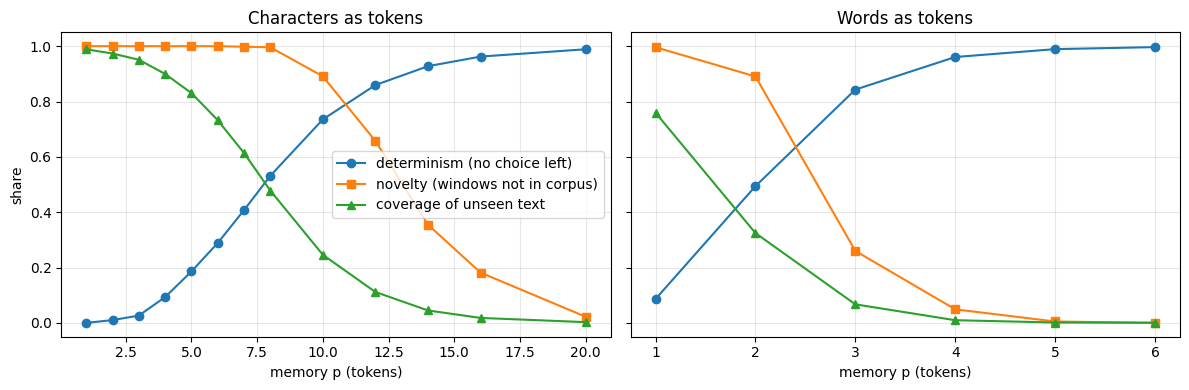

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, df, title in [(axes[0], char_df, "Characters as tokens"), (axes[1], word_df, "Words as tokens")]:
    ax.plot(df.p, df.determinism, "o-", label="determinism (no choice left)")
    ax.plot(df.p, df.novelty, "s-", label="novelty (windows not in corpus)")
    ax.plot(df.p, df.coverage, "^-", label="coverage of unseen text")
    ax.set_xlabel("memory p (tokens)"); ax.set_title(title); ax.grid(alpha=.3)
axes[0].set_ylabel("share"); axes[0].legend(loc="center right")
plt.tight_layout(); plt.show()

**How to read these curves.**

* Novelty starts at 100 % and collapses to ~0 %: past a certain memory, the model **recites**. Determinism rises symmetrically: the model has no choice left, because each context was seen exactly once.
* Coverage collapses too: the more the model memorizes, the less it can say about text it has not seen. A model with $p = 20$ characters is speechless on 95 % of unseen Hugo, and on 100 % of anything that is not Hugo.
* The trap closes **much sooner with words** ($p \approx 3$) than with characters ($p \approx 12$). Let us put both on the same axis, measured in characters of context, to compare fairly.

On this corpus a word is worth 6.1 characters on average


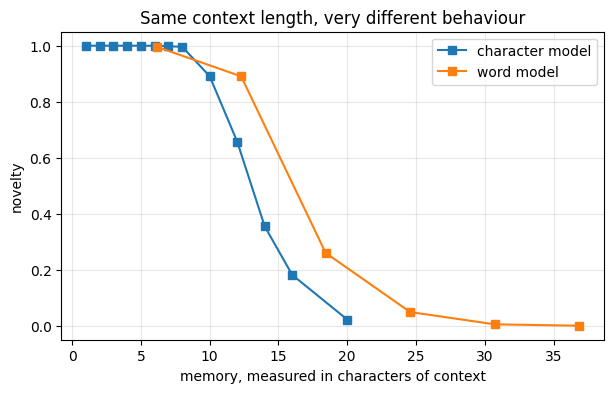

In [ ]:
avg_word_len = len(train_chars) / len(train_words)   # characters per word, including the space
print(f"On this corpus a word is worth {avg_word_len:.1f} characters on average")

plt.figure(figsize=(7, 4))
plt.plot(char_df.p, char_df.novelty, "s-", label="character model")
plt.plot(word_df.p * avg_word_len, word_df.novelty, "s-", label="word model")
plt.xlabel("memory, measured in characters of context"); plt.ylabel("novelty")
plt.title("Same context length, very different behaviour"); plt.grid(alpha=.3); plt.legend()
plt.show()

Measured in characters, the two curves nearly coincide. **What decides memorization is how much text the context spans, not how many tokens it takes.** The unit only fixes an exchange rate: three words or thirteen characters buy about the same memory. That exchange rate is not a detail. The models of sessions 2 and 3 pay for every token in the context, so a unit that packs more text per token makes the same memory cheaper.

Where the vocabulary size does bite is the third curve, **coverage**. Look at the word model at $p = 1$: even with a memory of a single word, a share of the words of an unseen slice of Hugo are simply unknown to it (a name, a rare inflection, a typo). A word model has *holes* that no memory setting can fill. The character model has none, and, as part B will show, neither do sub-word tokens.

### 4.1 Reciting versus improvising

Numbers are convincing; seeing the model *recite* is more fun. We seed a large-memory model with the first 20 characters of a passage of the corpus, and compare what it generates with the actual continuation in Hugo.

In [ ]:
def show_recitation(model, p, train, start, n=400):
    seed = train[start:start + p]
    gen = "".join(generate(model, p, n, seed, seq_like=train, rng=random.Random(0)))
    truth = train[start:start + p + n]
    # length of the exact common prefix
    k = 0
    while k < min(len(gen), len(truth)) and gen[k] == truth[k]:
        k += 1
    print(f"memory p={p}: the first {k} generated characters are an exact copy of the corpus "
          f"({k / len(gen):.0%} of the generation)\n")
    print("GENERATED :", gen[:300].replace("\n", " "))
    print("HUGO      :", truth[:300].replace("\n", " "))

start = train_chars.find("Depuis le 24 fevrier 1848")      # a note on the freedom of the press, 1848
if start < 0:
    start = train_chars.find(". ", 500_000) + 2
model20 = train_markov(train_chars, 20)
show_recitation(model20, 20, train_chars, start)

memory p=20: the first 374 generated characters are an exact copy of the corpus (89% of the generation)

GENERATED : Depuis le 24 fevrier 1848, les journaux etaient affranchis de l'impot du timbre.  Dans l'espoir de tuer, sous une loi d'impot, la presse republicaine, M. Louis Bonaparte fit presenter a l'assemblee une loi fiscale, qui retablissait le timbre sur les feuilles periodiques.  Une entente cordiale, scell
HUGO      : Depuis le 24 fevrier 1848, les journaux etaient affranchis de l'impot du timbre.  Dans l'espoir de tuer, sous une loi d'impot, la presse republicaine, M. Louis Bonaparte fit presenter a l'assemblee une loi fiscale, qui retablissait le timbre sur les feuilles periodiques.  Une entente cordiale, scell


In [ ]:
print("Same seed, same corpus, memory p=8:\n")
model8 = train_markov(train_chars, 8)
show_recitation(model8, 8, train_chars, start)
del model20, model8

Same seed, same corpus, memory p=8:



memory p=8: the first 10 generated characters are an exact copy of the corpus (2% of the generation)

GENERATED : Depuis le coupable de cette solennel, surtout commencant, et de ce calme, la meme chose; ce qui a profond interet que vous feriez cela? Entendons-nous Paris, apres le 13 juin 1849. La dissolutions d'un passant, quel que fut compris jusqu'au Nevado de Toluca; vous avez eu sans le senat, tout entier, 
HUGO      : Depuis le 24 fevrier 1848, les journaux etaient affranchis de l'impot du timbre.  Dans l'espoir de tuer, sous une loi d'impot, la presse republicaine, M. Louis Bonaparte fit presenter a l'assemblee une loi fiscale, qui retablissait le timbre sur les feuilles periodiques.  Une entente cordiale, scell


With $p=20$ the model is a photocopier: it reproduces the note word for word until it hits, by chance, a context that occurred twice in the corpus (and then it may switch to the other continuation, exactly as Shannon flipping to another page). With $p=8$ it improvises from the first line.

### 4.2 The other side: a large memory makes the model mute

The photocopier has a second defect. Prompt it with something that is not in the book and it has *nothing* to say.

In [ ]:
model12 = train_markov(train_chars, 12)
for prompt in ["Le peuple de Paris est ", "Les startups de l'IA sont ", "Waterloo! Waterloo! morne"]:
    out = continue_prompt(prompt, model12, 12, n=120)
    status = "(the model knows this context)" if len(out) > 12 else "(unseen context: speechless)"
    print(f"{prompt!r:32} -> {out[12:].replace(chr(10), ' ')!r} {status}")
del model12

'Le peuple de Paris est '        -> 'la capitale. Vous avez fait une lumiere. Il est bon peut-etre ete meme un peu trop pacifique, et, je le pense,--moi qui ' (the model knows this context)
"Les startups de l'IA sont "     -> '' (unseen context: speechless)
'Waterloo! Waterloo! morne'      -> '' (unseen context: speechless)


### 4.3 More data pushes the trap further away

Is memorization a property of the *model* or of the *data*? Let us repeat the character sweep with 250k, 1M and 4M training characters.

p= 4  contexts=   23,710  determinism=0.16  novelty=1.00  coverage=0.84
p= 6  contexts=   90,217  determinism=0.46  novelty=1.00  coverage=0.56


p= 8  contexts=  162,203  determinism=0.73  novelty=0.95  coverage=0.27
p=10  contexts=  206,234  determinism=0.87  novelty=0.62  coverage=0.10


p=12  contexts=  228,739  determinism=0.94  novelty=0.34  coverage=0.03


p=14  contexts=  239,438  determinism=0.97  novelty=0.10  coverage=0.01
p=16  contexts=  244,530  determinism=0.99  novelty=0.07  coverage=0.00


p=20  contexts=  248,135  determinism=1.00  novelty=0.00  coverage=0.00



...

p=10  contexts=2,377,187  determinism=0.69  novelty=0.90  coverage=0.35


p=12  contexts=3,076,312  determinism=0.84  novelty=0.70  coverage=0.18


p=14  contexts=3,486,798  determinism=0.91  novelty=0.38  coverage=0.08


p=16  contexts=3,705,367  determinism=0.96  novelty=0.19  coverage=0.03


p=20  contexts=3,882,388  determinism=0.99  novelty=0.03  coverage=0.01



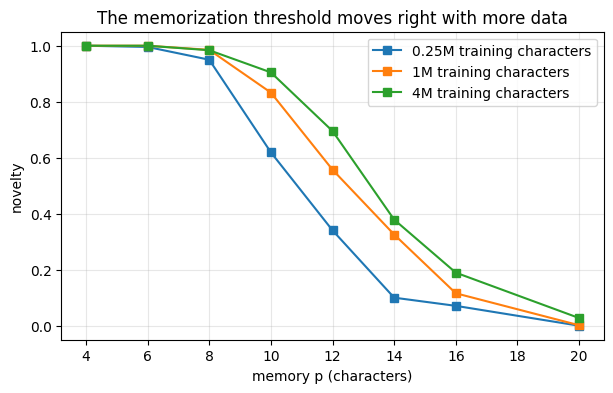

In [ ]:
plt.figure(figsize=(7, 4))
for N in [250_000, 1_000_000, 4_000_000]:
    rows = sweep(hugo[:N], heldout_chars, ps=[4, 6, 8, 10, 12, 14, 16, 20], L=30, n_gen=3000,
                 seq_like="", rng=random.Random(0))
    df = pd.DataFrame(rows)
    plt.plot(df.p, df.novelty, "s-", label=f"{N/1e6:g}M training characters")
    print()
plt.xlabel("memory p (characters)"); plt.ylabel("novelty"); plt.grid(alpha=.3); plt.legend()
plt.title("The memorization threshold moves right with more data")
plt.show()

The same model with more data memorizes later: **memory and data must grow together.** This is the first appearance of a theme that will come back with scaling laws (session 5): a model's capacity is only useful up to what the data can support; beyond that it stores the training set.

## 5. Where this leaves us

| unit       | vocabulary (this corpus) | tokens in the corpus | what goes wrong                                                                                           |
| ---------- | ------------------------ | -------------------- | --------------------------------------------------------------------------------------------------------- |
| characters | ~100                     | 13.5 M               | thirteen tokens of memory for what words do in three; a token carries almost no meaning                   |
| words      | ~170 k                   | 2.2 M                | holes: *any* new word is unknown; "amour" and "amours" share nothing; a huge vocabulary for 2 M positions |

Two escape routes, and the rest of the course is about both:

1. **Change the table.** Replace the dictionary of counts by a function that *shares statistics between similar contexts*: a neural network. That is session 2 (CNNs, RNNs) and session 3 (Transformers).
2. **Change the unit.** Find tokens that are neither characters nor words, so that the vocabulary is small enough to generalize and large enough to carry meaning. That is **tokenization**, part B of this session.

### 5.1 A first look at sub-word tokens

Before opening part B, run the exact same Markov code on a third kind of token: the sub-word tokens of GPT-2 (50,257 possible tokens). The tokenizer is a black box for now.

In [ ]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

train_tokens = tuple(enc.encode(train_chars))
heldout_tokens = tuple(enc.encode(heldout_chars))
print(f"{len(train_chars):,} characters -> {len(train_words):,} words -> {len(train_tokens):,} GPT-2 tokens")
print(f"{len(set(train_tokens)):,} distinct tokens used out of {enc.n_vocab:,}")
print("The first tokens of the corpus:", [enc.decode([t]) for t in train_tokens[:12]])

2,000,000 characters -> 325,536 words -> 729,876 GPT-2 tokens
9,131 distinct tokens used out of 50,257
The first tokens of the corpus: ['ACT', 'ES', ' ET', ' PAR', 'OL', 'ES', ' I', '\n\n', '\n\n', '\n', '\n', 'LE']


In [ ]:
print("Sub-word tokens (the same 2M characters)")
token_rows = sweep(train_tokens, heldout_tokens, ps=[1, 2, 3, 4, 5, 6, 8, 10], L=12, n_gen=1500,
                   seq_like=train_tokens, rng=random.Random(0))
token_df = pd.DataFrame(token_rows)

model3 = train_markov(train_tokens, 3)
print("\nA sample at p=3:", enc.decode(generate(model3, 3, 60, random_seed(train_tokens, 3), seq_like=train_tokens)).replace("\n", " "))
del model3

Sub-word tokens (the same 2M characters)


p= 1  contexts=    9,131  determinism=0.01  novelty=1.00  coverage=0.92

p= 2  contexts=  107,994  determinism=0.16  novelty=1.00  coverage=0.74


p= 3  contexts=  312,248  determinism=0.44  novelty=0.97  coverage=0.42


p= 4  contexts=  496,161  determinism=0.68  novelty=0.72  coverage=0.18


p= 5  contexts=  608,054  determinism=0.84  novelty=0.43  coverage=0.07


p= 6  contexts=  665,869  determinism=0.92  novelty=0.21  coverage=0.02


p= 8  contexts=  707,949  determinism=0.98  novelty=0.01  coverage=0.00


p=10  contexts=  719,473  determinism=0.99  novelty=0.00  coverage=0.00



A sample at p=3: avec tout! Les cures font des rapports de police.  Oui, tendons aujourd'hui, ces femmes qui sont en dehors. On ferait bien se garer de tout cela, un jour ou elles


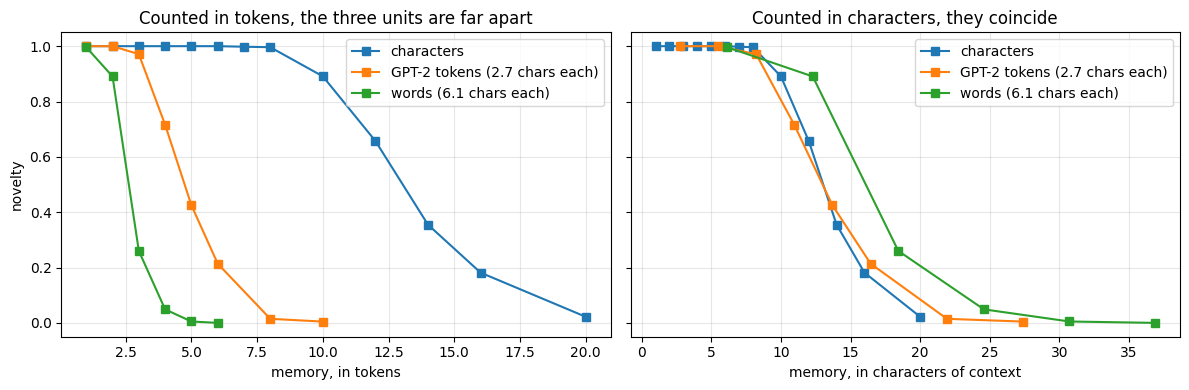

coverage of unseen text with a memory of one token:  characters 99%   GPT-2 tokens 92%   words 76%


In [ ]:
avg_token_len = len(train_chars) / len(train_tokens)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, scale in [(axes[0], dict(c=1, t=1, w=1)), (axes[1], dict(c=1, t=avg_token_len, w=avg_word_len))]:
    ax.plot(char_df.p * scale["c"], char_df.novelty, "s-", label="characters")
    ax.plot(token_df.p * scale["t"], token_df.novelty, "s-", label=f"GPT-2 tokens ({avg_token_len:.1f} chars each)")
    ax.plot(word_df.p * scale["w"], word_df.novelty, "s-", label=f"words ({avg_word_len:.1f} chars each)")
    ax.grid(alpha=.3); ax.legend()
axes[0].set_xlabel("memory, in tokens"); axes[0].set_ylabel("novelty"); axes[0].set_title("Counted in tokens, the three units are far apart")
axes[1].set_xlabel("memory, in characters of context"); axes[1].set_title("Counted in characters, they coincide")
plt.tight_layout(); plt.show()

print("coverage of unseen text with a memory of one token:  characters {:.0%}   GPT-2 tokens {:.0%}   words {:.0%}".format(
    char_df.coverage[0], token_df.coverage[0], word_df.coverage[0]))

Left panel: in tokens, words memorize at $p \approx 3$, GPT-2 tokens at $p \approx 5$, characters at $p \approx 13$. Right panel: in characters, the three curves coincide. Sub-word tokens buy memory at about 2.7 characters per token, halfway between the two extremes, and, unlike words, they leave no holes (compare the coverages printed above).

How is that vocabulary built, why does it differ between GPT, Mistral and Qwen, and how do the same tokens later encode *dialogue*, *tool calls* and *thinking*? Open **part B — Tokenization**.

---
*Further reading:* Shannon (1948), section 3, for the original game. Jurafsky & Martin, *Speech and Language Processing*, chapter 3 ("N-gram Language Models") for the classical treatment, including smoothing, the historical fix for the coverage problem.